In [5]:
!pip install transformers datasets torch scikit-learn matplotlib -q

In [6]:
import torch
import numpy as np
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from difflib import SequenceMatcher

# ── 模型加载 ──────────────────────────────────────────────
MODEL_NAME = "gpt2-xl"  # 比gpt2强很多
print(f"Loading {MODEL_NAME}...")
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()
tokenizer.pad_token = tokenizer.eos_token
print(f"Model loaded on {device}")

# ── 数据加载 ──────────────────────────────────────────────
dataset = load_dataset("trivia_qa", "rc.nocontext", split="validation[:500]")
print(f"Loaded {len(dataset)} samples")

# ── 软标签匹配 ────────────────────────────────────────────
def is_correct(model_answer, aliases):
    ans = model_answer.lower().strip()
    for a in aliases:
        a = a.lower().strip()
        if a in ans:
            return 1
        if SequenceMatcher(None, a, ans[:len(a)+10]).ratio() > 0.7:
            return 1
    return 0

# ── 单次推理：返回答案 + 所有uncertainty特征 ──────────────
def run_inference(question, max_new_tokens=40):
    prompt = f"Q: {question}\nA:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    gen_ids = outputs.sequences[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    # 只取第一行
    answer = answer.split("\n")[0].strip()

    log_probs, entropies = [], []
    for score in outputs.scores:
        probs = torch.softmax(score[0].float(), dim=-1)
        lp = torch.log(probs + 1e-10)
        best = probs.argmax()
        log_probs.append(lp[best].item())
        entropies.append(-(probs * lp).sum().item())

    return answer, log_probs, entropies

# ── self-consistency：采样3次，看答案是否一致 ─────────────
def run_sampled(question, n=3, max_new_tokens=40):
    prompt = f"Q: {question}\nA:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    answers = []
    with torch.no_grad():
        for _ in range(n):
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id,
            )
        gen = out[0][inputs["input_ids"].shape[1]:]
        ans = tokenizer.decode(gen, skip_special_tokens=True).split("\n")[0].strip()
        answers.append(ans)

    # 一致性：两两相似度均值
    sims = []
    for i in range(len(answers)):
        for j in range(i+1, len(answers)):
            sims.append(SequenceMatcher(None, answers[i], answers[j]).ratio())
    consistency = np.mean(sims) if sims else 0.0
    return consistency

# ── 主循环 ────────────────────────────────────────────────
results = []
for i, sample in enumerate(dataset):
    question = sample["question"]
    aliases = sample["answer"]["aliases"]

    # greedy推理
    answer, log_probs, entropies = run_inference(question)
    label = is_correct(answer, aliases)

    # self-consistency
    consistency = run_sampled(question, n=3)

    results.append({
        "question": question,
        "model_answer": answer,
        "reference": aliases[0] if aliases else "",
        "label": label,
        "avg_logprob":   np.mean(log_probs),
        "min_logprob":   np.min(log_probs),
        "std_logprob":   np.std(log_probs),
        "avg_entropy":   np.mean(entropies),
        "max_entropy":   np.max(entropies),
        "consistency":   consistency,
    })

    if (i+1) % 50 == 0:
        correct_so_far = sum(r["label"] for r in results)
        print(f"[{i+1}/500] correct={correct_so_far} | last_lp={np.mean(log_probs):.2f}")

df = pd.DataFrame(results)
df.to_csv("features.csv", index=False)
print(f"\nDone! Correct: {df['label'].sum()}/500 ({df['label'].mean()*100:.1f}%)")
print(df.head())

Loading gpt2-xl...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on cuda


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Loaded 500 samples
[50/500] correct=6 | last_lp=-1.10
[100/500] correct=12 | last_lp=-1.32
[150/500] correct=19 | last_lp=-0.82
[200/500] correct=29 | last_lp=-0.84
[250/500] correct=48 | last_lp=-0.57
[300/500] correct=62 | last_lp=-1.05
[350/500] correct=74 | last_lp=-0.45
[400/500] correct=79 | last_lp=-0.33
[450/500] correct=88 | last_lp=-1.15
[500/500] correct=96 | last_lp=-1.20

Done! Correct: 96/500 (19.2%)
                                            question  \
0              Who was the man behind The Chipmunks?   
1  Which Lloyd Webber musical premiered in the US...   
2  Who was the next British Prime Minister after ...   
3     Who had a 70s No 1 hit with Kiss You All Over?   
4  What claimed the life of singer Kathleen Ferrier?   

                                        model_answer  \
0  The Chipmunks were created by Jim Henson and w...   
1                               The Lion King (1994)   
2                                  Winston Churchill   
3                    

Label distribution: {0: 404, 1: 96}

Method                    AUROC    AUPRC
avg_logprob               0.683    0.895
min_logprob               0.694    0.903
std_logprob               0.715    0.908
avg_entropy               0.691    0.897
max_entropy               0.668    0.888
random                    0.519    0.813
combined (LR)             0.723    0.913


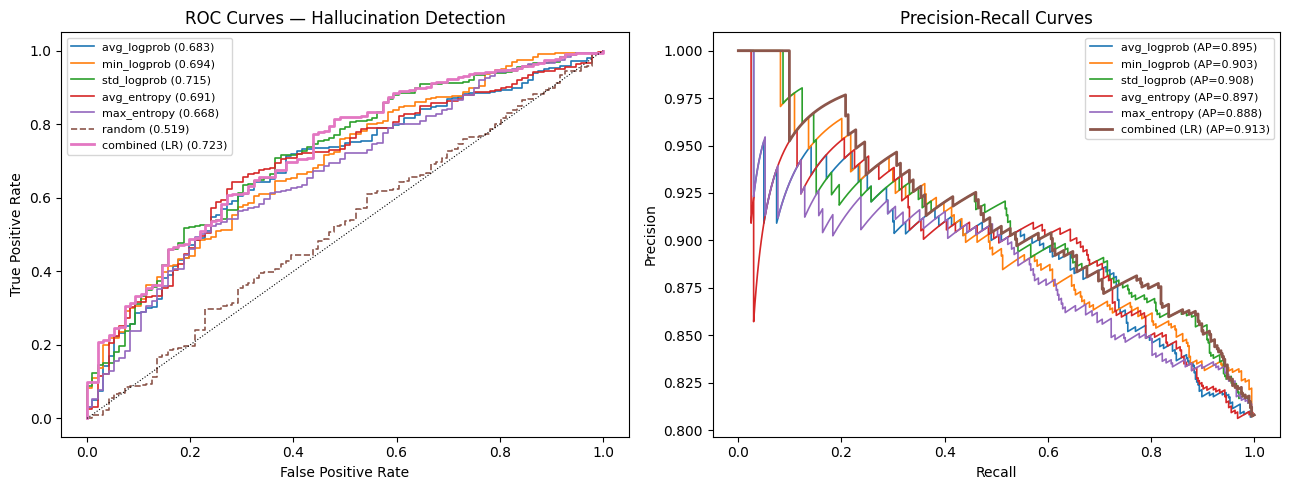

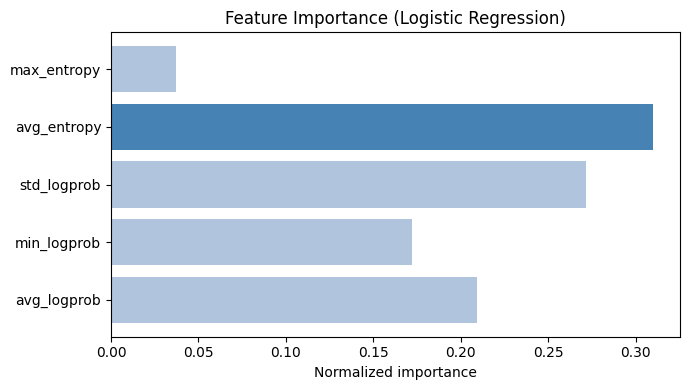

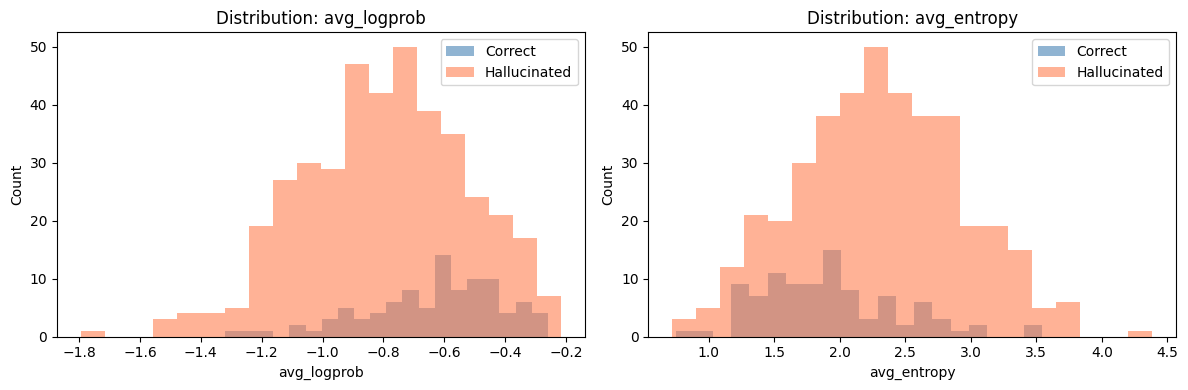

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("features.csv")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")

FEATURES = ["avg_logprob", "min_logprob", "std_logprob",
            "avg_entropy", "max_entropy"]

# ── AUROC表格 ─────────────────────────────────────────────
# 规则：logprob越低=越可能hallucinated，entropy越高=越可能hallucinated
hallucination_scores = {
    "avg_logprob":  -df["avg_logprob"],
    "min_logprob":  -df["min_logprob"],
    "std_logprob":   df["std_logprob"],
    "avg_entropy":   df["avg_entropy"],
    "max_entropy":   df["max_entropy"],
    "random":        np.random.rand(len(df)),
}

print("\n" + "="*42)
print(f"{'Method':<22} {'AUROC':>8} {'AUPRC':>8}")
print("="*42)
for name, score in hallucination_scores.items():
    auroc = roc_auc_score(1 - df["label"], score)
    auprc = average_precision_score(1 - df["label"], score)
    print(f"{name:<22} {auroc:>8.3f} {auprc:>8.3f}")

# combined
X = df[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
clf = LogisticRegression(max_iter=1000).fit(X_scaled, 1 - df["label"])
combined = clf.predict_proba(X_scaled)[:, 1]
auroc_c = roc_auc_score(1 - df["label"], combined)
auprc_c = average_precision_score(1 - df["label"], combined)
print(f"{'combined (LR)':<22} {auroc_c:>8.3f} {auprc_c:>8.3f}")
print("="*42)

# ── 图1: ROC + PR ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_methods = {k: v for k, v in hallucination_scores.items()}
plot_methods["combined (LR)"] = combined

for ax, curve_type in zip(axes, ["roc", "pr"]):
    for name, score in plot_methods.items():
        ls = "--" if name == "random" else "-"
        lw = 2 if name == "combined (LR)" else 1.2
        if curve_type == "roc":
            fpr, tpr, _ = roc_curve(1 - df["label"], score)
            val = roc_auc_score(1 - df["label"], score)
            ax.plot(fpr, tpr, ls, lw=lw, label=f"{name} ({val:.3f})")
        else:
            if name == "random": continue
            p, r, _ = precision_recall_curve(1 - df["label"], score)
            val = average_precision_score(1 - df["label"], score)
            ax.plot(r, p, ls, lw=lw, label=f"{name} (AP={val:.3f})")

    if curve_type == "roc":
        ax.plot([0,1],[0,1],"k:",lw=0.8)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title("ROC Curves — Hallucination Detection")
    else:
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title("Precision-Recall Curves")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("evaluation_curves.png", dpi=150)
plt.show()

# ── 图2: 特征重要性 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
imp = np.abs(clf.coef_[0])
imp = imp / imp.sum()
colors = ["steelblue" if i == imp.argmax() else "lightsteelblue" for i in range(len(FEATURES))]
ax.barh(FEATURES, imp, color=colors)
ax.set_xlabel("Normalized importance")
ax.set_title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# ── 图3: 分布对比（correct vs hallucinated）───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["avg_logprob", "avg_entropy"]):
    ax.hist(df[df["label"]==1][feat], bins=20, alpha=0.6, label="Correct", color="steelblue")
    ax.hist(df[df["label"]==0][feat], bins=20, alpha=0.6, label="Hallucinated", color="coral")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution: {feat}")
    ax.legend()
plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()

# ── 下载 ──────────────────────────────────────────────────
from google.colab import files
for f in ["features.csv", "evaluation_curves.png",
          "feature_importance.png", "distributions.png"]:
    files.download(f)

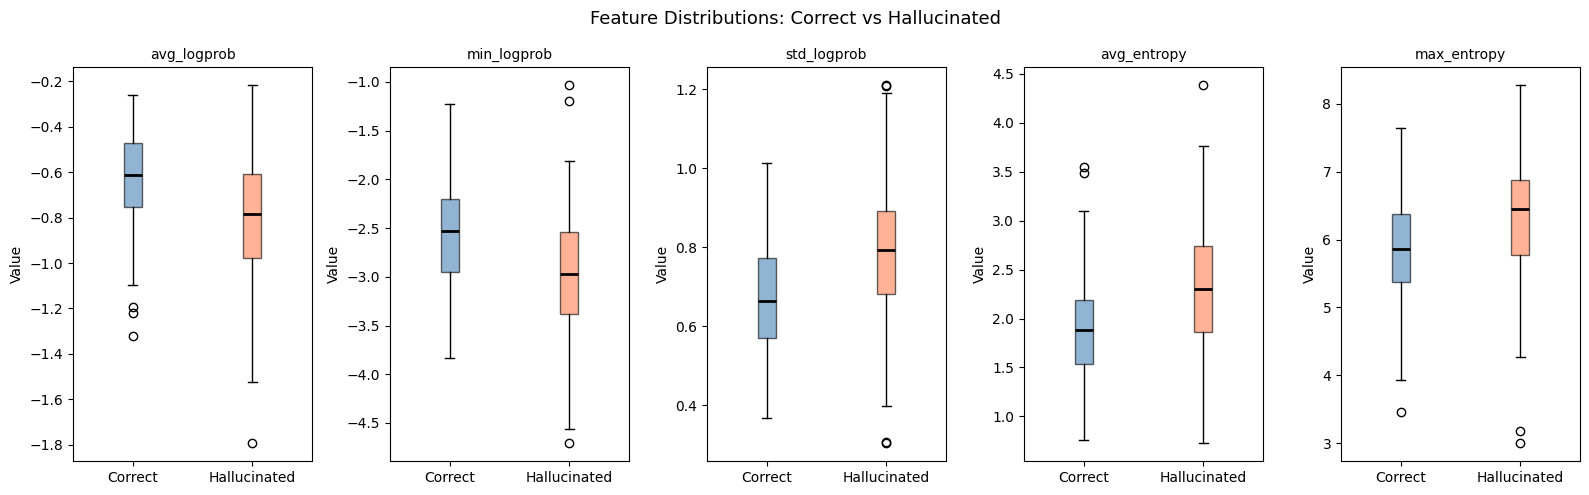

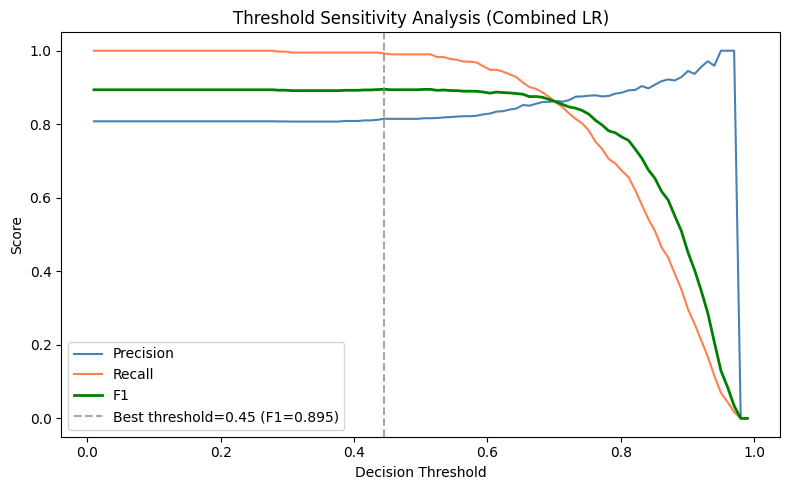

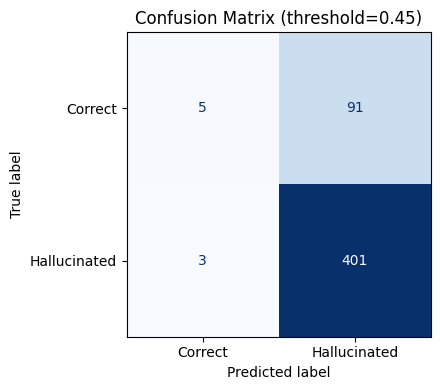

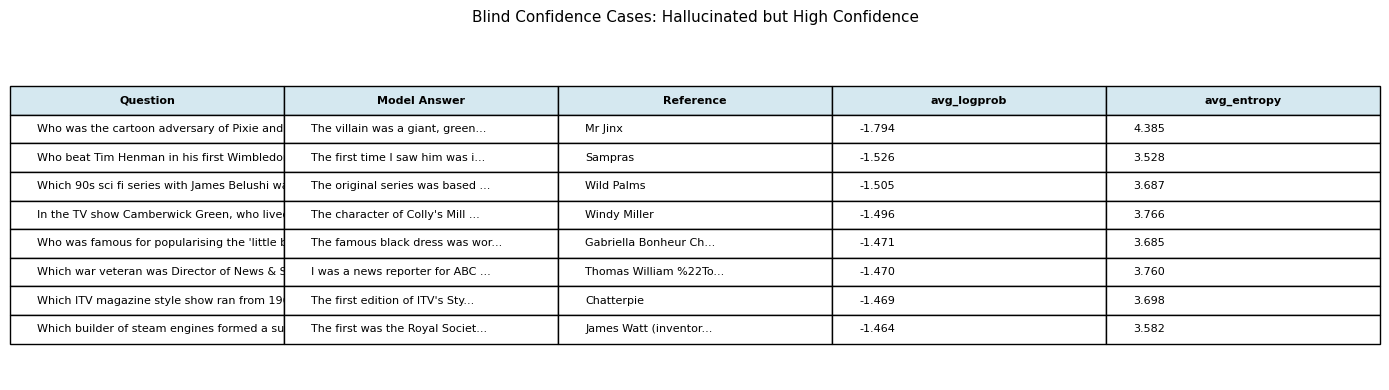

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Best F1: 0.895 at threshold 0.45
Precision: 0.815, Recall: 0.993


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("features.csv")
FEATURES = ["avg_logprob", "min_logprob", "std_logprob", "avg_entropy", "max_entropy"]
y = 1 - df["label"]

X = df[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
clf = LogisticRegression(max_iter=1000).fit(X_scaled, y)
combined_score = clf.predict_proba(X_scaled)[:, 1]

# ── 图1: Box plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax, feat in zip(axes, FEATURES):
    data_correct = df[df["label"]==1][feat]
    data_halluc  = df[df["label"]==0][feat]
    bp = ax.boxplot([data_correct, data_halluc],
               tick_labels=["Correct", "Hallucinated"],
               patch_artist=True,
               medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("coral")
    bp["boxes"][1].set_alpha(0.6)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel("Value")
plt.suptitle("Feature Distributions: Correct vs Hallucinated", fontsize=13)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()

# ── 图2: Threshold sensitivity ────────────────────────────
thresholds = np.linspace(0.01, 0.99, 100)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (combined_score >= t).astype(int)
    tp = ((preds==1) & (y==1)).sum()
    fp = ((preds==1) & (y==0)).sum()
    fn = ((preds==0) & (y==1)).sum()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label="Precision", color="steelblue")
ax.plot(thresholds, recalls,    label="Recall",    color="coral")
ax.plot(thresholds, f1s,        label="F1",        color="green", linewidth=2)
ax.axvline(best_t, color="gray", linestyle="--", alpha=0.7,
           label=f"Best threshold={best_t:.2f} (F1={best_f1:.3f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity Analysis (Combined LR)")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=150)
plt.show()

# ── 图3: Confusion matrix ─────────────────────────────────
preds_best = (combined_score >= best_t).astype(int)
cm = confusion_matrix(y, preds_best)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Correct", "Hallucinated"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix (threshold={best_t:.2f})")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── 图4: Error analysis table ─────────────────────────────
df["combined_score"] = combined_score
blind_conf = df[df["label"]==0].nsmallest(8, "avg_logprob")[
    ["question","model_answer","reference","avg_logprob","avg_entropy"]
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")
table_data = []
for _, row in blind_conf.iterrows():
    table_data.append([
        row["question"][:55]+"..." if len(row["question"])>55 else row["question"],
        row["model_answer"][:30]+"..." if len(str(row["model_answer"]))>30 else str(row["model_answer"]),
        row["reference"][:20]+"..." if len(str(row["reference"]))>20 else str(row["reference"]),
        f"{row['avg_logprob']:.3f}",
        f"{row['avg_entropy']:.3f}",
    ])
tbl = ax.table(
    cellText=table_data,
    colLabels=["Question", "Model Answer", "Reference", "avg_logprob", "avg_entropy"],
    loc="center", cellLoc="left"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#D5E8F0")
        cell.set_text_props(fontweight="bold")
ax.set_title("Blind Confidence Cases: Hallucinated but High Confidence", fontsize=11, pad=20)
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 下载 ──────────────────────────────────────────────────
from google.colab import files
for f in ["boxplots.png","threshold_sensitivity.png","confusion_matrix.png","error_analysis.png"]:
    files.download(f)

print(f"\nBest F1: {best_f1:.3f} at threshold {best_t:.2f}")
tp = ((preds_best==1)&(y==1)).sum()
fp = ((preds_best==1)&(y==0)).sum()
fn = ((preds_best==0)&(y==1)).sum()
print(f"Precision: {tp/(tp+fp):.3f}, Recall: {tp/(tp+fn):.3f}")